<a href="https://colab.research.google.com/github/moeenessa31-lgtm/Final-Project/blob/main/Credit_Card_Fraud_Detection_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download('mlg-ulb/creditcardfraud')

print('Data source import complete.')


# Credit Card Fraud Detection: Unsupervised Anomaly Detection and Deep Learning

**Project:** Anomaly Detection and Customer Segmentation Using Unsupervised Machine Learning and Deep Learning  
**Dataset:** Credit Card Fraud Detection Dataset  

**Team Members**  
- A'SEM ZAKARIYA ALI ELFRIEH — Student ID: 180293  
- HAMZA MOEEN RASHEED ESSA — Student ID: 183174
- MOHAMMAD ZIAD ABDELMAJEED AL ROUSAN — Student ID: 180601

This notebook contains the cleaned final implementation. Exploratory failed attempts, repeated trial plots, and unnecessary cells were removed. Tuning tables are kept only where they justify the selected final parameters.

## 1. Imports and Dataset Loading

The dataset is loaded from the Kaggle path used in the project environment. The `Class` column is kept only for evaluation: `0` means genuine transaction and `1` means fraud.

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve,
    silhouette_score, davies_bouldin_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Download latest version
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path + "/creditcard.csv")
print("Original shape:", df.shape)
df.head()

2026-05-22 21:20:47.258861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779484847.502578      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779484847.571554      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779484848.132072      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779484848.132120      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779484848.132123      57 computation_placer.cc:177] computation placer alr

Original shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Initial Data Exploration

This section checks the dataset structure, class imbalance, missing values, and duplicated rows.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
print("Class counts:")
print(df["Class"].value_counts())
print("Class percentages:")
print(df["Class"].value_counts(normalize=True) * 100)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate rows by class:")
print(df[df.duplicated()]["Class"].value_counts())

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64
Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Missing values: 0
Duplicate rows: 1081
Duplicate rows by class:
Class
0    1062
1      19
Name: count, dtype: int64


## 3. Data Cleaning and Scaling

Duplicate rows are removed. RobustScaler is used because anomaly detection is sensitive to feature scale, and transaction data may contain extreme values. `Class` is not included in the model input.

In [ ]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_rows - len(df)} duplicate rows.")
print("Cleaned shape:", df.shape)

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled shape:", X_scaled.shape)
X_scaled.head()

Removed 1081 duplicate rows.
Cleaned shape: (283726, 31)
Scaled shape: (283726, 30)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.995290,-0.618360,-0.097622,1.229434,0.880878,-0.218773,0.632648,0.176974,0.143677,0.335739,...,0.910319,0.026861,0.253199,-0.320939,0.032627,0.168017,-0.241512,0.816068,-0.246698,1.774718
1,-0.995290,0.524849,0.144367,-0.007034,0.295891,0.087159,0.165383,-0.106558,0.118241,-0.163546,...,-0.019525,-0.473668,-0.602596,0.363373,-0.479559,0.225835,0.314036,-0.064639,0.026214,-0.268530
2,-0.995279,-0.617709,-1.002505,0.831270,0.252882,-0.345402,1.780431,0.668400,0.422384,-1.178892,...,1.704013,0.669336,0.714327,2.974843,-0.919547,-0.514733,-0.153300,-0.351138,-0.541896,4.959811
3,-0.995279,-0.442046,-0.177906,0.841592,-0.529031,0.033147,1.305834,0.175202,0.665139,-1.075980,...,-0.422670,-0.190254,-0.001308,-0.578965,-1.531860,0.944541,-0.299382,0.378404,0.382702,1.411487
4,-0.995267,-0.528050,0.581026,0.714142,0.267510,-0.271669,0.318307,0.491620,-0.547078,0.701771,...,1.366197,0.048275,0.739164,-0.408139,0.126231,-0.332690,0.977848,1.346586,1.555108,0.667362


## 4. PCA Dimensionality Reduction

PCA is applied after scaling. The number of components is selected using cumulative explained variance. A 95% threshold is used as a practical balance between information preservation and dimensionality reduction.

In [ ]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_table = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance": cumulative_variance
})
pca_variance_table.head(10)

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.232908,0.232908
1,PC2,0.104850,0.337759
2,PC3,0.099300,0.437059
3,PC4,0.081467,0.518526
4,PC5,0.073271,0.591797
5,PC6,0.065917,0.657714
6,PC7,0.050163,0.707877
7,PC8,0.022133,0.730010
8,PC9,0.021251,0.751261
9,PC10,0.019730,0.770990


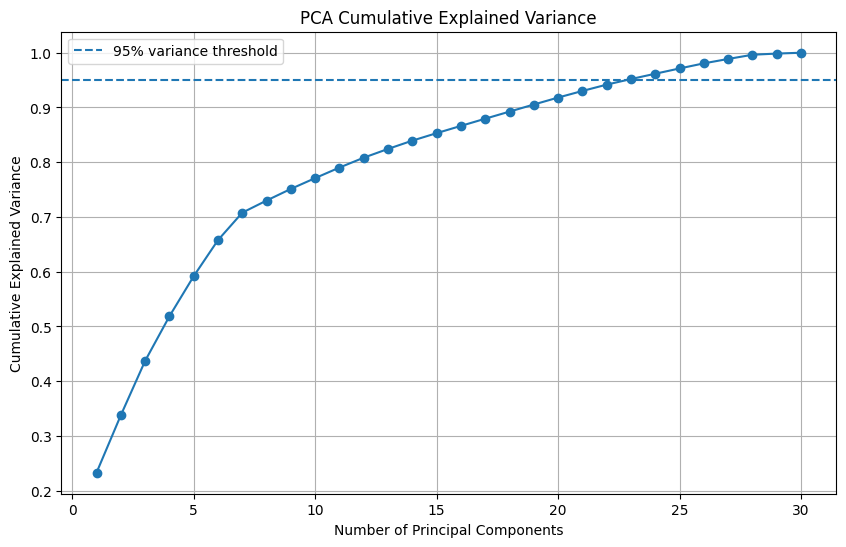

Number of components needed for 95% variance: 23
Cumulative variance at selected components: 0.9519306048803944


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print("Number of components needed for 95% variance:", n_components_95)
print("Cumulative variance at selected components:", cumulative_variance[n_components_95 - 1])

In [ ]:
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)
X_pca_95 = pd.DataFrame(X_pca_95, columns=[f"PC{i+1}" for i in range(n_components_95)])
print("PCA-reduced shape:", X_pca_95.shape)
X_pca_95.head()

PCA-reduced shape: (283726, 23)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,1.077014,-0.372959,0.706665,0.415740,0.209937,-0.427759,-0.092344,0.390250,0.163230,0.146854,...,0.084403,0.618606,1.230453,-0.200735,-0.526858,0.695692,0.865774,-0.614697,0.553021,-0.361407
1,-1.285498,0.129479,-0.001307,0.111362,0.241415,0.113455,-0.489775,0.082494,-0.033043,-0.182195,...,0.242545,0.225775,0.569366,-0.328982,0.031524,-0.636885,0.911633,0.103961,0.162033,0.352875
2,4.303859,-0.373114,-0.601030,1.023019,1.149025,3.039980,0.142732,0.876007,0.860218,0.276443,...,1.492596,0.949223,-1.251070,-2.412645,-2.761959,0.455985,1.026058,-0.549411,0.293762,-0.754987
3,0.390171,0.347538,0.509091,0.427246,-1.103184,-0.191134,-0.434502,0.807700,0.600307,-0.047278,...,-0.613545,0.595101,-1.244652,-0.809200,-1.495487,0.121412,0.771766,-0.397831,2.331862,0.471771
4,0.153759,1.228655,1.708687,-0.057176,1.085090,-0.951241,0.161061,0.538576,-0.389751,0.819902,...,-0.070452,0.154096,1.188313,0.044209,-0.237449,1.197905,0.871061,0.654348,0.221392,-0.557950


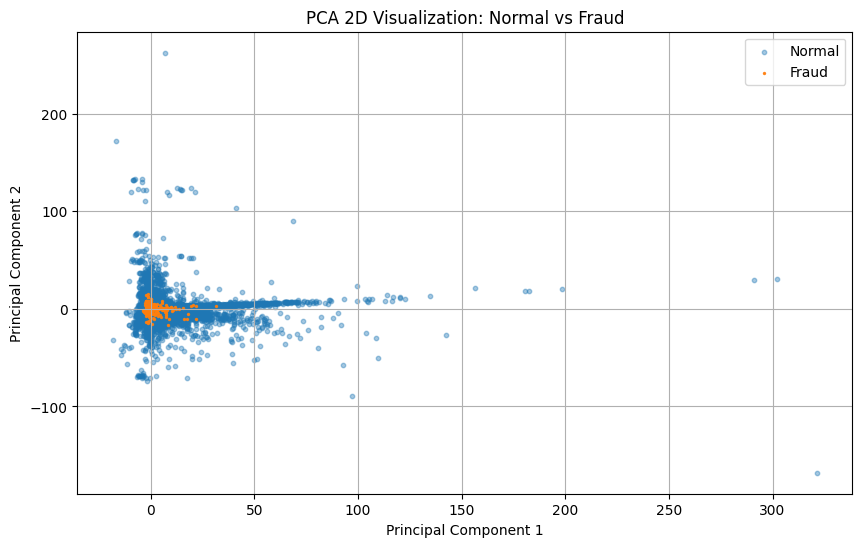

PC1 + PC2 cumulative variance: 0.3377586533231832


In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["Class"] = y.values

normal_pca = pca_df[pca_df["Class"] == 0]
fraud_pca = pca_df[pca_df["Class"] == 1]
pca_sample = pd.concat([normal_pca, fraud_pca])

plt.figure(figsize=(10, 6))

plt.scatter(pca_sample[pca_sample["Class"] == 0]["PC1"],
            pca_sample[pca_sample["Class"] == 0]["PC2"],
            alpha=0.4, s=10, label="Normal")

plt.scatter(pca_sample[pca_sample["Class"] == 1]["PC1"],
            pca_sample[pca_sample["Class"] == 1]["PC2"],
            alpha=0.9, s=2, label="Fraud")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization: Normal vs Fraud")
plt.legend()
plt.grid(True)
plt.show()

print("PC1 + PC2 cumulative variance:", cumulative_variance[1])

## 5. t-SNE Visualization

Full-data t-SNE was computationally expensive for more than 283,000 cleaned transactions. Therefore, a representative visualization subset is used: all fraud transactions plus 10,000 randomly selected normal transactions. Labels are used only for coloring, not for fitting t-SNE.

In [ ]:
pca_with_class = X_pca_95.copy()
pca_with_class["Class"] = y.values

fraud_data = pca_with_class[pca_with_class["Class"] == 1]
normal_data = pca_with_class[pca_with_class["Class"] == 0].sample(n=10000, random_state=RANDOM_STATE)

tsne_subset = pd.concat([normal_data, fraud_data], axis=0)
tsne_subset = tsne_subset.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_tsne_subset = tsne_subset.drop("Class", axis=1)
y_tsne_subset = tsne_subset["Class"]

print("t-SNE subset shape:", X_tsne_subset.shape)
print("Class distribution:")
print(y_tsne_subset.value_counts())

t-SNE subset shape: (10473, 23)
Class distribution:
Class
0    10000
1      473
Name: count, dtype: int64


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10473 samples in 0.001s...
[t-SNE] Computed neighbors for 10473 samples in 0.693s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10473
[t-SNE] Computed conditional probabilities for sample 2000 / 10473
[t-SNE] Computed conditional probabilities for sample 3000 / 10473
[t-SNE] Computed conditional probabilities for sample 4000 / 10473
[t-SNE] Computed conditional probabilities for sample 5000 / 10473
[t-SNE] Computed conditional probabilities for sample 6000 / 10473
[t-SNE] Computed conditional probabilities for sample 7000 / 10473
[t-SNE] Computed conditional probabilities for sample 8000 / 10473
[t-SNE] Computed conditional probabilities for sample 9000 / 10473
[t-SNE] Computed conditional probabilities for sample 10000 / 10473
[t-SNE] Computed conditional probabilities for sample 10473 / 10473
[t-SNE] Mean sigma: 1.011736
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.038597
[t-SNE] KL 

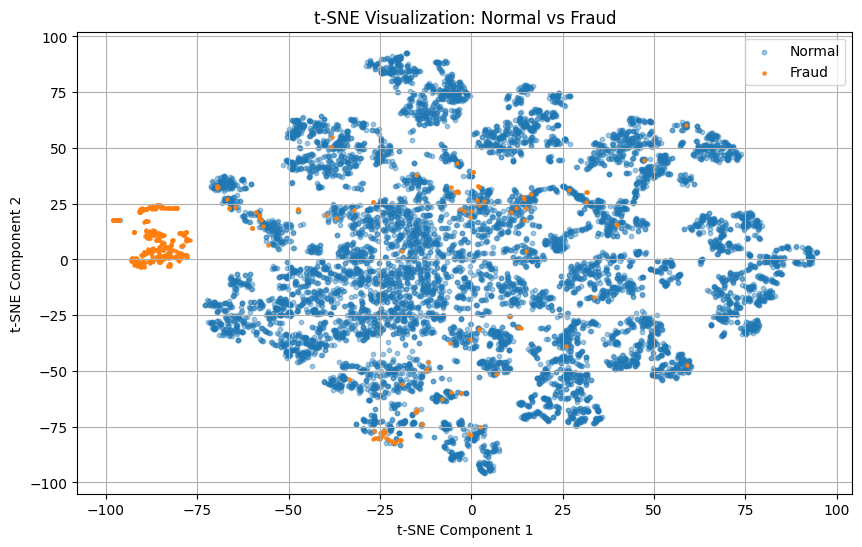

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
    verbose=1
)

X_tsne = tsne.fit_transform(X_tsne_subset)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["Class"] = y_tsne_subset.values

plt.figure(figsize=(10, 6))

plt.scatter(tsne_df[tsne_df["Class"] == 0]["TSNE1"],
            tsne_df[tsne_df["Class"] == 0]["TSNE2"],
            alpha=0.4, s=10, label="Normal")

plt.scatter(tsne_df[tsne_df["Class"] == 1]["TSNE1"],
            tsne_df[tsne_df["Class"] == 1]["TSNE2"],
            alpha=0.9, s=5, label="Fraud")

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization: Normal vs Fraud")
plt.legend()
plt.grid(True)
plt.show()

## 6. DBSCAN Clustering and Noise Detection

DBSCAN is used on the PCA-reduced t-SNE subset features (`X_tsne_subset`), not directly on t-SNE coordinates. The t-SNE coordinates are used only for visualization. Parameter tuning compares anomaly detection metrics and clustering quality metrics.

k-distance percentiles:
50% percentile: 2.293179666720004
75% percentile: 3.402740955265011
90% percentile: 5.425840784686856
95% percentile: 7.786403459164798
97% percentile: 10.121734652503594
98% percentile: 12.054069194401052
99% percentile: 16.90938173167934
99.5% percentile: 21.796892880561064
99.9% percentile: 64.7860028023397


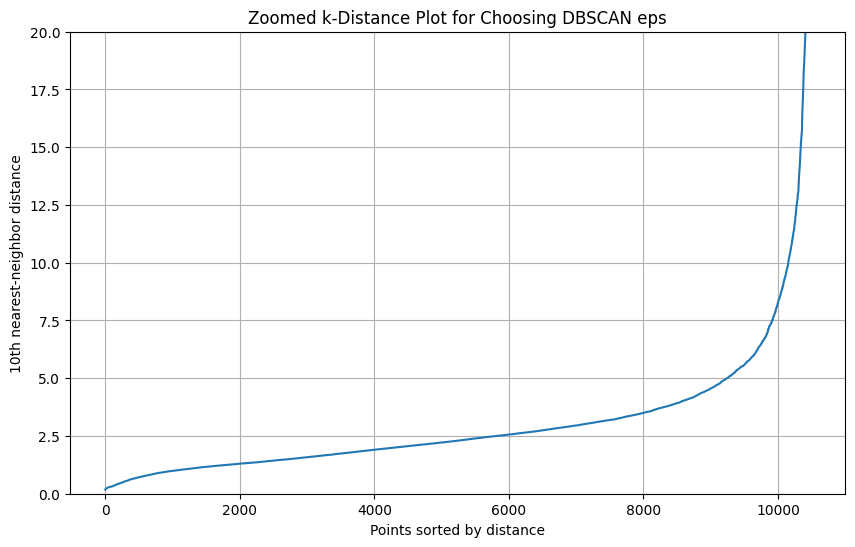

In [ ]:
min_samples_for_plot = 10
neighbors = NearestNeighbors(n_neighbors=min_samples_for_plot)
neighbors_fit = neighbors.fit(X_tsne_subset)
distances, indices = neighbors_fit.kneighbors(X_tsne_subset)
k_distances = np.sort(distances[:, min_samples_for_plot - 1])

print("k-distance percentiles:")
for p in [50, 75, 90, 95, 97, 98, 99, 99.5, 99.9]:
    print(f"{p}% percentile:", np.percentile(k_distances, p))

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.ylim(0, 20)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples_for_plot}th nearest-neighbor distance")
plt.title("Zoomed k-Distance Plot for Choosing DBSCAN eps")
plt.grid(True)
plt.show()

In [ ]:
min_samples_values = [5, 10, 20]
eps_values = [3, 4, 5, 6, 7, 8, 9, 10, 12]

dbscan_tuning_rows = []

for min_s in min_samples_values:
    for eps in eps_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s, metric="euclidean", n_jobs=-1)
        labels = dbscan.fit_predict(X_tsne_subset)
        y_true = y_tsne_subset.values
        y_pred = (labels == -1).astype(int)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_percentage = (n_noise / len(labels)) * 100
        fraud_detected = np.sum((y_true == 1) & (y_pred == 1))

        clustered_mask = labels != -1
        X_clustered = X_tsne_subset[clustered_mask]
        labels_clustered = labels[clustered_mask]
        if len(set(labels_clustered)) > 1:
            sil = silhouette_score(X_clustered, labels_clustered)
            dbi = davies_bouldin_score(X_clustered, labels_clustered)
        else:
            sil = np.nan
            dbi = np.nan

        dbscan_tuning_rows.append({
            "eps": eps,
            "min_samples": min_s,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "noise_percentage": noise_percentage,
            "fraud_detected": fraud_detected,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1_score": f1_score(y_true, y_pred, zero_division=0),
            "silhouette_score": sil,
            "davies_bouldin_index": dbi
        })

dbscan_tuning_results = pd.DataFrame(dbscan_tuning_rows)
dbscan_tuning_results.sort_values(by="f1_score", ascending=False).head(10)

,eps,min_samples,clusters,noise_points,noise_percentage,fraud_detected,precision,recall,f1_score,silhouette_score,davies_bouldin_index
21,6,20,2,699,6.674305,292,0.417740,0.617336,0.498294,0.553681,0.851324
22,7,20,1,547,5.222954,250,0.457038,0.528541,0.490196,NaN,NaN
23,8,20,1,422,4.029409,217,0.514218,0.458774,0.484916,NaN,NaN
20,5,20,3,976,9.319202,350,0.358607,0.739958,0.483092,0.305337,1.117936
11,5,10,3,888,8.478946,323,0.363739,0.682875,0.474651,0.299512,1.158483
13,7,10,3,453,4.325408,216,0.476821,0.456660,0.466523,0.725638,0.352769
12,6,10,3,604,5.767211,247,0.408940,0.522199,0.458682,0.564102,0.671934
24,9,20,1,341,3.255992,179,0.524927,0.378436,0.439803,NaN,NaN
10,4,10,3,1387,13.243579,388,0.279740,0.820296,0.417204,0.326244,0.982985
25,10,20,1,290,2.769025,159,0.548276,0.336152,0.416776,NaN,NaN


In [ ]:
final_eps = 6
final_min_samples = 20

final_dbscan = DBSCAN(eps=final_eps, min_samples=final_min_samples, metric="euclidean", n_jobs=-1)
final_dbscan_labels = final_dbscan.fit_predict(X_tsne_subset)

final_dbscan_results = pd.DataFrame({
    "Actual_Class": y_tsne_subset.values,
    "DBSCAN_Label": final_dbscan_labels
})
final_dbscan_results["Predicted_Anomaly"] = (final_dbscan_results["DBSCAN_Label"] == -1).astype(int)

print("Final Tuned DBSCAN")
print("eps:", final_eps)
print("min_samples:", final_min_samples)
print("Cluster distribution:")
print(pd.Series(final_dbscan_labels).value_counts().sort_index())
print("Confusion Matrix:")
print(confusion_matrix(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"]))
print("Classification Report:")
print(classification_report(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"], target_names=["Normal", "Fraud"]))

clustered_mask = final_dbscan_labels != -1
X_clustered = X_tsne_subset[clustered_mask]
labels_clustered = final_dbscan_labels[clustered_mask]
print("Silhouette Score:", silhouette_score(X_clustered, labels_clustered))
print("Davies-Bouldin Index:", davies_bouldin_score(X_clustered, labels_clustered))

Final Tuned DBSCAN
eps: 6
min_samples: 20
Cluster distribution:
-1     699
 0    9671
 1     103
Name: count, dtype: int64
Confusion Matrix:
[[9593  407]
 [ 181  292]]
Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97     10000
       Fraud       0.42      0.62      0.50       473

    accuracy                           0.94     10473
   macro avg       0.70      0.79      0.73     10473
weighted avg       0.96      0.94      0.95     10473

Silhouette Score: 0.5536813310949223
Davies-Bouldin Index: 0.8513243649159518


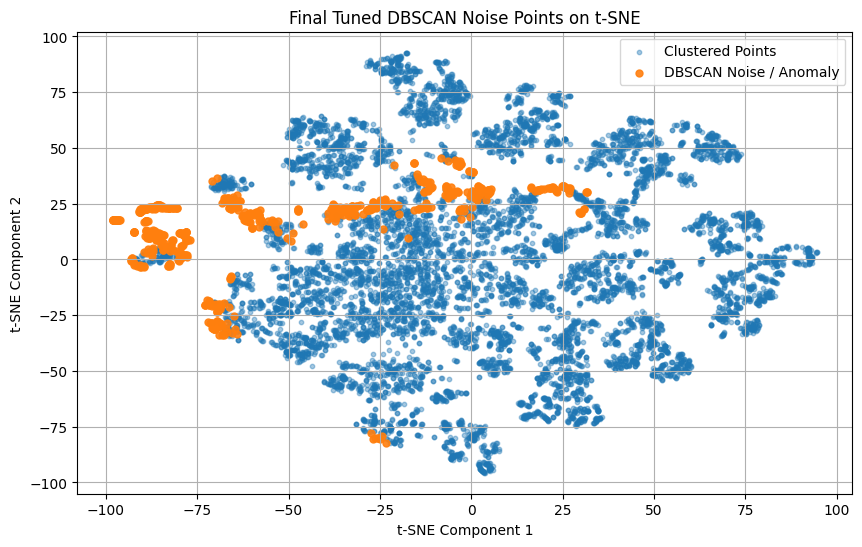

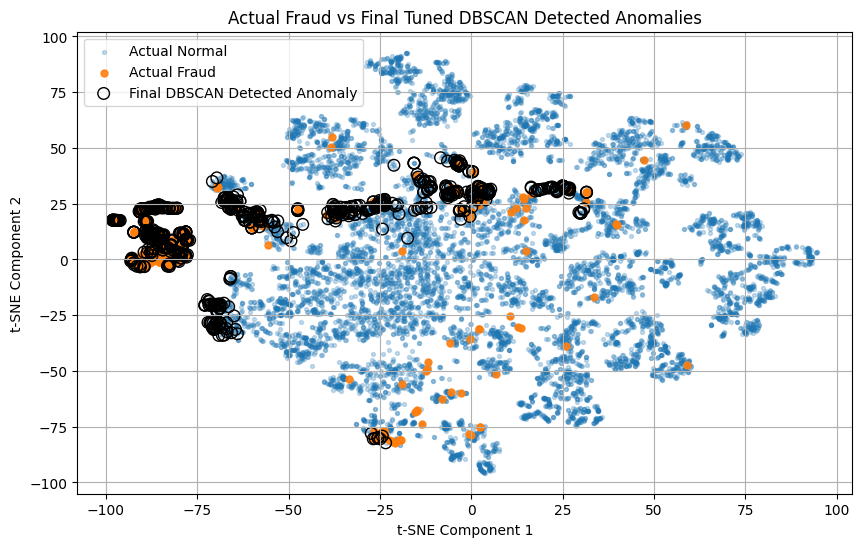

In [ ]:
tsne_df["Final_DBSCAN_Label"] = final_dbscan_labels
tsne_df["Final_DBSCAN_Anomaly"] = (final_dbscan_labels == -1).astype(int)

plt.figure(figsize=(10, 6))

plt.scatter(tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 0]["TSNE1"],
            tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 0]["TSNE2"],
            alpha=0.4, s=10, label="Clustered Points")

plt.scatter(tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE1"],
            tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE2"],
            alpha=0.9, s=25, label="DBSCAN Noise / Anomaly")

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Final Tuned DBSCAN Noise Points on t-SNE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(tsne_df[tsne_df["Class"] == 0]["TSNE1"],
            tsne_df[tsne_df["Class"] == 0]["TSNE2"],
            alpha=0.25, s=8, label="Actual Normal")

plt.scatter(tsne_df[tsne_df["Class"] == 1]["TSNE1"],
            tsne_df[tsne_df["Class"] == 1]["TSNE2"],
            alpha=0.9, s=25, label="Actual Fraud")

plt.scatter(tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE1"],
            tsne_df[tsne_df["Final_DBSCAN_Anomaly"] == 1]["TSNE2"],
            facecolors="none", edgecolors="black", s=70, label="Final DBSCAN Detected Anomaly")

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Actual Fraud vs Final Tuned DBSCAN Detected Anomalies")
plt.legend()
plt.grid(True)
plt.show()

## 7. One-Class SVM Anomaly Detection

One-Class SVM is trained only on normal transactions. A normal training subset is used for computational efficiency, while evaluation is performed on the full test set.

In [ ]:
X_ocsvm = X_pca_95.reset_index(drop=True)
y_ocsvm = y.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_ocsvm,
    y_ocsvm,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_ocsvm
)

X_train_normal = X_train[y_train == 0]
X_train_normal_sample = X_train_normal.sample(n=20000, random_state=RANDOM_STATE)

print("Full data shape:", X_ocsvm.shape)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Normal training sample shape:", X_train_normal_sample.shape)
print("Train class distribution:")
print(y_train.value_counts())
print("Test class distribution:")
print(y_test.value_counts())

Full data shape: (283726, 23)
Training set shape: (226980, 23)
Test set shape: (56746, 23)
Normal training sample shape: (20000, 23)
Train class distribution:
Class
0    226602
1       378
Name: count, dtype: int64
Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
# Coarse tuning of nu
nu_values = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]
nu_rows = []
for nu in nu_values:
    model = OneClassSVM(kernel="rbf", nu=nu, gamma="scale")
    model.fit(X_train_normal_sample)
    pred = np.where(model.predict(X_test) == -1, 1, 0)
    nu_rows.append({
        "nu": nu,
        "anomaly_count": np.sum(pred == 1),
        "fraud_detected": np.sum((y_test.values == 1) & (pred == 1)),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0)
    })
ocsvm_nu_results = pd.DataFrame(nu_rows)
ocsvm_nu_results.sort_values(by="f1_score", ascending=False)

,nu,anomaly_count,fraud_detected,precision,recall,f1_score
2,0.005,1644,77,0.046837,0.810526,0.088557
0,0.001,1645,77,0.046809,0.810526,0.088506
1,0.003,1645,77,0.046809,0.810526,0.088506
3,0.010,1645,77,0.046809,0.810526,0.088506
4,0.020,1734,77,0.044406,0.810526,0.084199
5,0.050,3012,79,0.026228,0.831579,0.050853


In [ ]:
# Tuning gamma around the best nu
best_nu = 0.005
gamma_values = [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
gamma_rows = []
for gamma in gamma_values:
    model = OneClassSVM(kernel="rbf", nu=best_nu, gamma=gamma)
    model.fit(X_train_normal_sample)
    pred = np.where(model.predict(X_test) == -1, 1, 0)
    gamma_rows.append({
        "nu": best_nu,
        "gamma": gamma,
        "anomaly_count": np.sum(pred == 1),
        "fraud_detected": np.sum((y_test.values == 1) & (pred == 1)),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1_score": f1_score(y_test, pred, zero_division=0)
    })
ocsvm_gamma_results = pd.DataFrame(gamma_rows)
ocsvm_gamma_results.sort_values(by="f1_score", ascending=False)

,nu,gamma,anomaly_count,fraud_detected,precision,recall,f1_score
0,0.005,0.002,449,56,0.124722,0.589474,0.205882
2,0.005,0.004,599,70,0.116861,0.736842,0.201729
1,0.005,0.003,522,61,0.116858,0.642105,0.197731
3,0.005,0.005,681,73,0.107195,0.768421,0.188144
4,0.005,0.006,768,75,0.097656,0.789474,0.173812
5,0.005,0.007,837,75,0.089606,0.789474,0.160944
6,0.005,0.008,924,75,0.081169,0.789474,0.147203


In [ ]:
final_ocsvm = OneClassSVM(kernel="rbf", nu=0.005, gamma=0.004)
final_ocsvm.fit(X_train_normal_sample)
final_ocsvm_pred = np.where(final_ocsvm.predict(X_test) == -1, 1, 0)

print("Final One-Class SVM: kernel=rbf, nu=0.005, gamma=0.004")
print("Prediction counts:")
print(pd.Series(final_ocsvm_pred).value_counts())
print("Confusion Matrix:")
print(confusion_matrix(y_test, final_ocsvm_pred))
print("Classification Report:")
print(classification_report(y_test, final_ocsvm_pred, target_names=["Normal", "Fraud"]))

Final One-Class SVM: kernel=rbf, nu=0.005, gamma=0.004
Prediction counts:
0    56147
1      599
Name: count, dtype: int64
Confusion Matrix:
[[56122   529]
 [   25    70]]
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56651
       Fraud       0.12      0.74      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.86      0.60     56746
weighted avg       1.00      0.99      0.99     56746



## 8. Autoencoder with TensorFlow/Keras

The Autoencoder is trained only on normal transactions. Reconstruction error is used as the anomaly score. A threshold is selected from normal training reconstruction errors.

In [ ]:
X_train_auto = X_train_normal.values.astype("float32")
X_test_auto = X_test.values.astype("float32")
y_test_auto = y_test.values

print("Autoencoder training data shape:", X_train_auto.shape)
print("Autoencoder test data shape:", X_test_auto.shape)
print("Test labels shape:", y_test_auto.shape)
print("Test class distribution:")
print(pd.Series(y_test_auto).value_counts())

Autoencoder training data shape: (226602, 23)
Autoencoder test data shape: (56746, 23)
Test labels shape: (56746,)
Test class distribution:
0    56651
1       95
Name: count, dtype: int64


In [ ]:
input_dim = X_train_auto.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation="relu")(input_layer)
encoded = Dense(8, activation="relu")(encoded)
latent = Dense(4, activation="relu")(encoded)
decoded = Dense(8, activation="relu")(latent)
decoded = Dense(16, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

2026-05-22 21:24:31.010252: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 23)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │           391 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131 (4.42 KB)

 Trainable params: 1,131 (4.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_auto,
    X_train_auto,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 2.0091 - val_loss: 1.2615
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1381 - val_loss: 1.0079
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9645 - val_loss: 0.9060
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8726 - val_loss: 0.8554
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8230 - val_loss: 0.8140
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7864 - val_loss: 0.7830
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7622 - val_loss: 0.7659
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7475 - val_loss: 0.7531
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7355 - val_loss: 0.7419
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7260 - val_loss: 0.7325
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7159 - val_loss: 0.7249
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

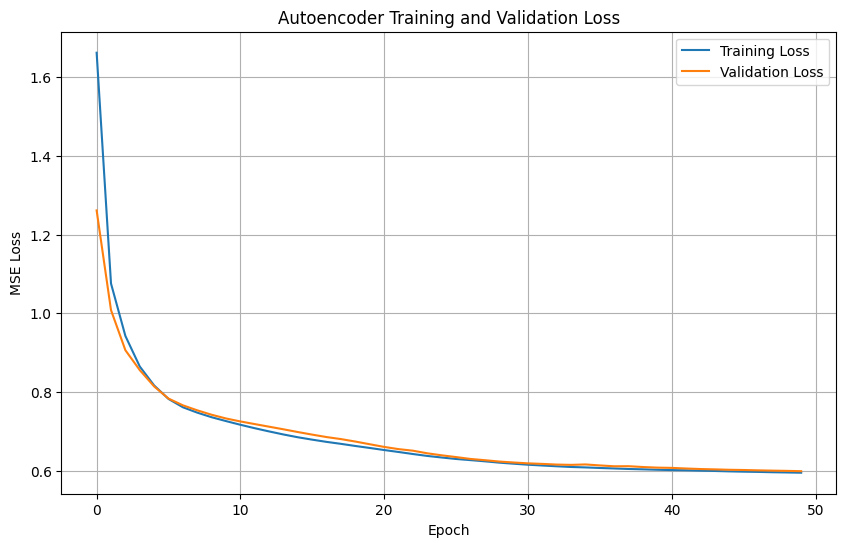

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_test_reconstructed = autoencoder.predict(X_test_auto)
reconstruction_errors = np.mean(np.square(X_test_auto - X_test_reconstructed), axis=1)

autoencoder_results = pd.DataFrame({
    "Actual_Class": y_test_auto,
    "Reconstruction_Error": reconstruction_errors
})

autoencoder_results.groupby("Actual_Class")["Reconstruction_Error"].describe()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


,count,mean,std,min,25%,50%,75%,max
Actual_Class,,,,,,,,
0,56651.0,0.602444,2.305679,0.035838,0.239942,0.403441,0.650594,300.102722
1,95.0,20.989204,28.510656,0.161493,4.653308,9.325654,21.323819,114.127357


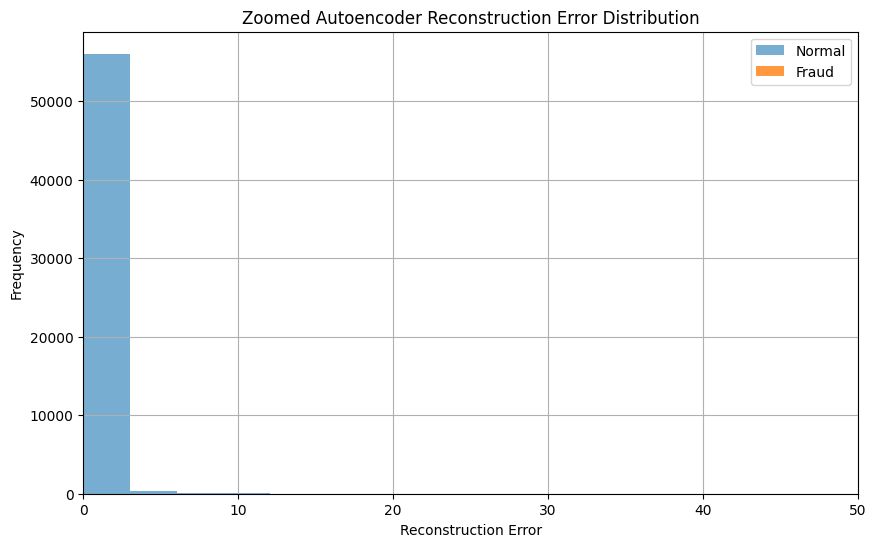

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(autoencoder_results[autoencoder_results["Actual_Class"] == 0]["Reconstruction_Error"],
         bins=100, alpha=0.6, label="Normal")
plt.hist(autoencoder_results[autoencoder_results["Actual_Class"] == 1]["Reconstruction_Error"],
         bins=100, alpha=0.8, label="Fraud")
plt.xlim(0, 50)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Zoomed Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_train_reconstructed = autoencoder.predict(X_train_auto)
train_reconstruction_errors = np.mean(np.square(X_train_auto - X_train_reconstructed), axis=1)

threshold_percentiles = [95, 97, 98, 99, 99.5, 99.7, 99.9]
threshold_rows = []
for p in threshold_percentiles:
    threshold = np.percentile(train_reconstruction_errors, p)
    pred = (autoencoder_results["Reconstruction_Error"] > threshold).astype(int)
    threshold_rows.append({
        "percentile": p,
        "threshold": threshold,
        "anomaly_count": np.sum(pred == 1),
        "fraud_detected": np.sum((y_test_auto == 1) & (pred == 1)),
        "precision": precision_score(y_test_auto, pred, zero_division=0),
        "recall": recall_score(y_test_auto, pred, zero_division=0),
        "f1_score": f1_score(y_test_auto, pred, zero_division=0)
    })
autoencoder_threshold_results = pd.DataFrame(threshold_rows)
autoencoder_threshold_results.sort_values(by="f1_score", ascending=False)

7082/7082 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


,percentile,threshold,anomaly_count,fraud_detected,precision,recall,f1_score
6,99.9,16.371069,93,31,0.333333,0.326316,0.329787
5,99.7,7.440701,242,52,0.214876,0.547368,0.308605
4,99.5,5.170305,352,65,0.184659,0.684211,0.290828
3,99.0,3.108477,646,74,0.114551,0.778947,0.199730
2,98.0,2.027636,1184,77,0.065034,0.810526,0.120407
1,97.0,1.674232,1778,78,0.043870,0.821053,0.083289
0,95.0,1.364251,2915,79,0.027101,0.831579,0.052492


In [ ]:
final_threshold_percentile = 99.7
final_autoencoder_threshold = np.percentile(train_reconstruction_errors, final_threshold_percentile)
final_autoencoder_pred = (autoencoder_results["Reconstruction_Error"] > final_autoencoder_threshold).astype(int)

print("Final Autoencoder threshold percentile:", final_threshold_percentile)
print("Threshold:", final_autoencoder_threshold)
print("Prediction counts:")
print(pd.Series(final_autoencoder_pred).value_counts())
print("Confusion Matrix:")
print(confusion_matrix(y_test_auto, final_autoencoder_pred))
print("Classification Report:")
print(classification_report(y_test_auto, final_autoencoder_pred, target_names=["Normal", "Fraud"]))

Final Autoencoder threshold percentile: 99.7
Threshold: 7.4407015
Prediction counts:
Reconstruction_Error
0    56504
1      242
Name: count, dtype: int64
Confusion Matrix:
[[56461   190]
 [   43    52]]
Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.21      0.55      0.31        95

    accuracy                           1.00     56746
   macro avg       0.61      0.77      0.65     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
encoder = Model(inputs=input_layer, outputs=latent)
X_test_latent = encoder.predict(X_test_auto)

latent_df = pd.DataFrame(X_test_latent, columns=["Latent_1", "Latent_2", "Latent_3", "Latent_4"])
latent_df["Class"] = y_test_auto

print("Latent representation shape:", latent_df.shape)
latent_df.head()

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Latent representation shape: (56746, 5)


,Latent_1,Latent_2,Latent_3,Latent_4,Class
0,3.575389,5.736339,4.552884,6.337224,0
1,4.792337,10.489128,4.860188,7.999108,0
2,4.339033,8.177996,5.545027,7.139524,0
3,5.109165,6.892809,7.416858,10.834429,0
4,4.018822,5.526748,4.808751,6.182206,0


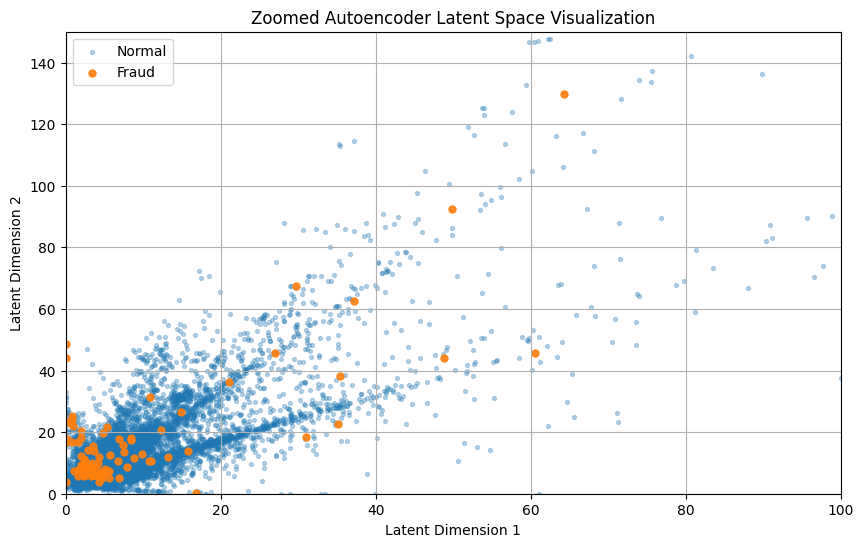

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(latent_df[latent_df["Class"] == 0]["Latent_1"],
            latent_df[latent_df["Class"] == 0]["Latent_2"],
            alpha=0.3, s=8, label="Normal")

plt.scatter(latent_df[latent_df["Class"] == 1]["Latent_1"],
            latent_df[latent_df["Class"] == 1]["Latent_2"],
            alpha=0.9, s=25, label="Fraud")

plt.xlim(0, 100)
plt.ylim(0, 150)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Zoomed Autoencoder Latent Space Visualization")
plt.legend()
plt.grid(True)
plt.show()

## 9. Model Comparison

This section compares the tuned models. DBSCAN was evaluated on the t-SNE subset, while One-Class SVM and Autoencoder were evaluated on the full test set. This distinction is important when interpreting the results.

In [ ]:
ocsvm_scores = -final_ocsvm.decision_function(X_test)
autoencoder_scores = autoencoder_results["Reconstruction_Error"].values

final_comparison = pd.DataFrame([
    {
        "Model": "DBSCAN",
        "Data Used": "t-SNE subset",
        "Main Parameters": "eps=6, min_samples=20",
        "Accuracy": accuracy_score(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"]),
        "Precision": precision_score(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"], zero_division=0),
        "Recall": recall_score(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"], zero_division=0),
        "F1-score": f1_score(final_dbscan_results["Actual_Class"], final_dbscan_results["Predicted_Anomaly"], zero_division=0),
        "ROC-AUC": np.nan,
        "PR-AUC": np.nan
    },
    {
        "Model": "One-Class SVM",
        "Data Used": "Full test set",
        "Main Parameters": "kernel=rbf, nu=0.005, gamma=0.004",
        "Accuracy": accuracy_score(y_test, final_ocsvm_pred),
        "Precision": precision_score(y_test, final_ocsvm_pred, zero_division=0),
        "Recall": recall_score(y_test, final_ocsvm_pred, zero_division=0),
        "F1-score": f1_score(y_test, final_ocsvm_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, ocsvm_scores),
        "PR-AUC": average_precision_score(y_test, ocsvm_scores)
    },
    {
        "Model": "Autoencoder",
        "Data Used": "Full test set",
        "Main Parameters": "threshold=99.7 percentile",
        "Accuracy": accuracy_score(y_test_auto, final_autoencoder_pred),
        "Precision": precision_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "Recall": recall_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "F1-score": f1_score(y_test_auto, final_autoencoder_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_auto, autoencoder_scores),
        "PR-AUC": average_precision_score(y_test_auto, autoencoder_scores)
    }
])

final_comparison_rounded = final_comparison.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]:
    final_comparison_rounded[col] = final_comparison_rounded[col].round(3)
final_comparison_rounded

,Model,Data Used,Main Parameters,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,DBSCAN,t-SNE subset,"eps=6, min_samples=20",0.944,0.418,0.617,0.498,NaN,NaN
1,One-Class SVM,Full test set,"kernel=rbf, nu=0.005, gamma=0.004",0.990,0.117,0.737,0.202,0.912,0.142
2,Autoencoder,Full test set,threshold=99.7 percentile,0.996,0.215,0.547,0.309,0.939,0.246


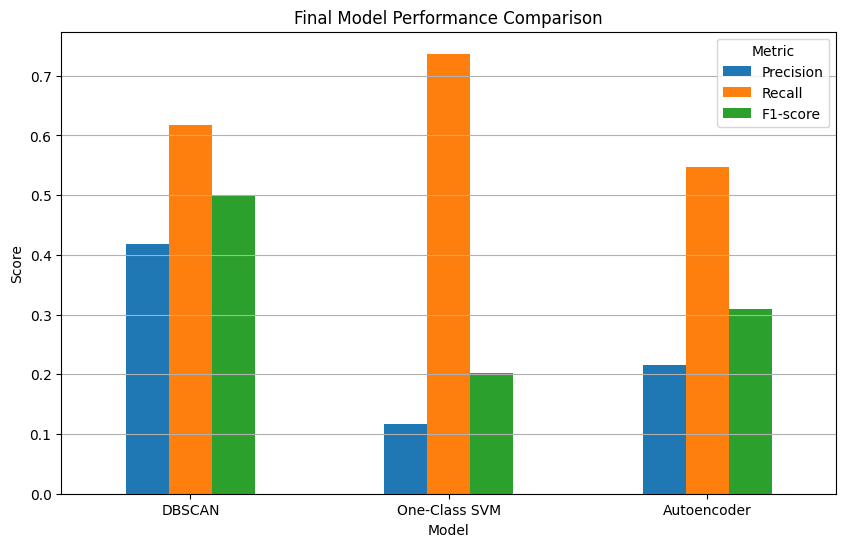

In [ ]:
comparison_plot = final_comparison.copy()
metrics = ["Precision", "Recall", "F1-score"]
comparison_plot.set_index("Model")[metrics].plot(kind="bar", figsize=(10, 6))
plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(title="Metric")
plt.show()

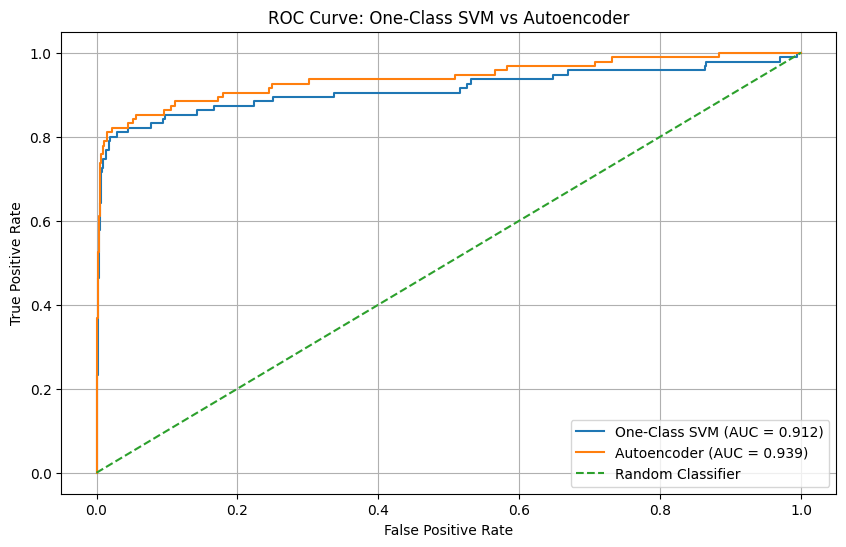

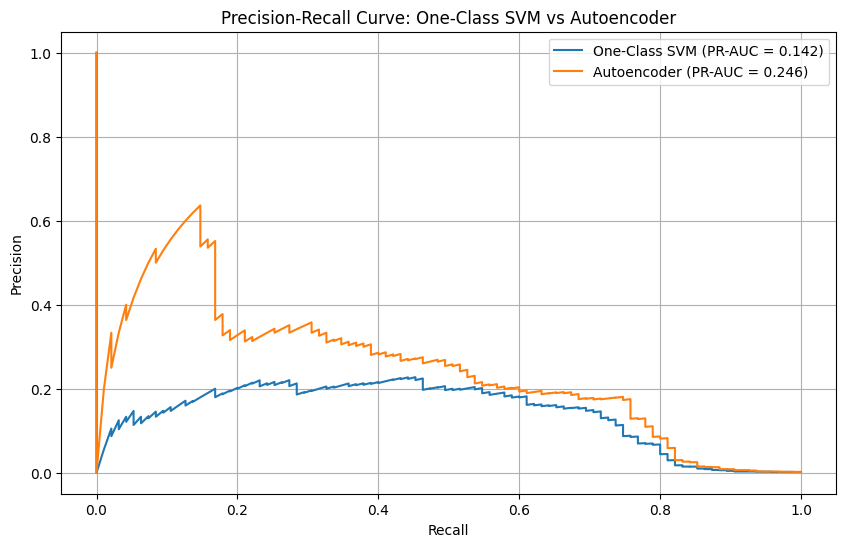

In [ ]:
fpr_ocsvm, tpr_ocsvm, _ = roc_curve(y_test, ocsvm_scores)
fpr_auto, tpr_auto, _ = roc_curve(y_test_auto, autoencoder_scores)

plt.figure(figsize=(10, 6))
plt.plot(fpr_ocsvm, tpr_ocsvm, label=f"One-Class SVM (AUC = {auc(fpr_ocsvm, tpr_ocsvm):.3f})")
plt.plot(fpr_auto, tpr_auto, label=f"Autoencoder (AUC = {auc(fpr_auto, tpr_auto):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: One-Class SVM vs Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

precision_ocsvm, recall_ocsvm, _ = precision_recall_curve(y_test, ocsvm_scores)
precision_auto, recall_auto, _ = precision_recall_curve(y_test_auto, autoencoder_scores)

plt.figure(figsize=(10, 6))

plt.plot(recall_ocsvm, precision_ocsvm,
         label=f"One-Class SVM (PR-AUC = {average_precision_score(y_test, ocsvm_scores):.3f})")

plt.plot(recall_auto, precision_auto,
         label=f"Autoencoder (PR-AUC = {average_precision_score(y_test_auto, autoencoder_scores):.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: One-Class SVM vs Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

## 10. Final Conclusion

DBSCAN was useful for density-based clustering and noise detection, and it achieved the highest F1-score on the visualization subset. However, it was not evaluated on the same full test set as the other models, so it is best interpreted as an exploratory clustering/anomaly method.

One-Class SVM achieved the highest fraud recall on the full test set, so it is useful when the priority is catching as many fraud cases as possible, even with more false positives.

The Autoencoder achieved the strongest full-test-set ranking performance, with the highest ROC-AUC and PR-AUC among the full-test-set models. It also provided learned latent representations and reconstruction errors, satisfying the deep learning requirements of the project.